# Lab 11

## Section 1: PyTorch 



## Import Torch

In [3]:
import torch #torch-advanced array aape
import torch.nn as nn # nn means neural network modules

#nn.Linear -> linear layer
#nn.Conv2d -> convolutional layer
#nn atle like neural network build karvanu toolbox

import torch.optim as optim # optim means optimization algorithms-> update the weights of the model to reduce the loss

import pandas as pd

In [2]:
pip install torch torchvision 

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━ 76.0/79.4 MB 49.3 kB/s eta 0:01:09m
Resuming download torch-2.10.0-2-cp311-none-macosx_11_0_arm64.whl (76.0 MB/79.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 MB 549.5 kB/s  0:00:06m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 870.1 kB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 473.5 kB/s  0:00:04 eta 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [torchvision] [torchvision]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgra

### Task 1: GPU/Device Agnostic Code
**Goal:** Write code that runs on CPU, CUDA, or MPS (Mac) automatically.


In [ ]:
#cuda -> nvidia gpu par run karva mate
#mps -> apple silicon par run karva mate

#cuda parallel computation kare

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

#randn - random normal distribution
#torch.randn(2, 3) here (2,3) is shape of tensor
#torch.randn(2, 3)
#tensor([[ 0.25, -1.12,  0.67],
#        [-0.45,  1.30, -0.89]])
sample_input = torch.randn(1, 10).to(device)
type(sample_input)

Using device: mps


torch.Tensor

In [ ]:
#torch is core library for tensor operations and neural network building
#torchvision is extension library for image data

## Section 2: MNIST Project 
Step 1: What is MNIST & Downloading Data

Concept: MNIST is the "Hello World" of Machine Learning. It contains 70,000 images of handwritten digits (0-9).

The Goal: Teach the computer to look at a grid of pixels and say "That is a 7".

The Data: Each image is grayscale and exactly 28×28


In [ ]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [ ]:
#mnist -> 60000 training images and 10000 test images of handwritten digits (0-9)

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor() #converts image to tensor
)

# transform=ToTensor() converts the image (0-255) to a Torch Tensor (0.0-1.0)

#niche ans madyo a 4 epoch no madyo, accuracy 100% aavi che, and aa traning accuracy che


100.0%
100.0%
100.0%
100.0%


In [ ]:
# Do for Testing
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

#aama train= false che atle vadheli 10000 testing ni lese

## Visualizing One Image & Understanding Shapes

In [8]:
len(training_data)

60000

In [9]:
len(test_data)

10000

In [ ]:
img,label=training_data[0] 
#training_data[0] returns a tuple of (image, label)

#data = training_data[0] -> first sample from dataset
#img = data[0]
#label = data[1]

In [ ]:
img.shape 
#(1, 28, 28) -> 1 channel (grayscale), 28x28 pixels

torch.Size([1, 28, 28])

In [15]:
img.squeeze().shape
#(28, 28) -> squeeze() removes dimensions of size 1

torch.Size([28, 28])

## Display one Image in MatplotLib

In [16]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Label: 5')

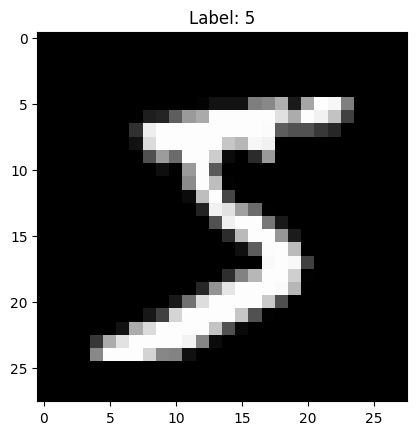

In [17]:
#print image
plt.imshow(img.squeeze(),cmap="gray")
plt.title(f"Label: {label}")

# Calculation for the Input Layer

Concept: We are building a Linear (Feed-Forward) Network,

A Linear Layer consists of neurons in a single vertical line.

Our image is a square grid (28×28).

The Division: We must "cut" the image row by row and stack them into one long line.

The Calculation:

Height×Width=Total Input Features
28×28=784
So, our Input Layer must have 784 neurons.

In [57]:
img, label = training_data[1]

In [59]:
img.squeeze().shape

torch.Size([28, 28])

## The Architecture (1 Input, 1 Hidden, 1 Output
The Concept: We will build the simplest standard network.

Input Layer (784): Receives the pixels.

Hidden Layer (128): The "brain" that learns shapes (loops, lines). We pick 128 because it's enough to learn but not too big.

Output Layer (10): The final decision. We have 10 digits (0-9), so we need 10 output scores.

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Understanding Batch Size (The Stack)

The Concept: Think of the model like a teacher grading exams.

Batch Size = 1: The teacher grades 1 exam, updates the grade book, then picks up the next exam. (Too slow).

Batch Size = 64: The teacher picks up a stack of 64 exams, grades them all at once, and updates the grade book one time for the whole stack. (Much faster).

We use DataLoader to create these "stacks" for us.

In [ ]:
from torch.utils.data import DataLoader

# Create stacks
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
# do for Test_data

print(len(train_loader),"--",len(test_loader))


938 -- 157


## The Training Loop

In [67]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [73]:
train()

Batch 0: Loss = 2.2587
Batch 100: Loss = 0.4718
Batch 200: Loss = 0.2364
Batch 300: Loss = 0.3395
Batch 400: Loss = 0.1946
Batch 500: Loss = 0.3256
Batch 600: Loss = 0.1262
Batch 700: Loss = 0.2901
Batch 800: Loss = 0.4627
Batch 900: Loss = 0.0775


Test Accuracy: 94.6%
